# MPL (modelo) 

In [19]:
import numpy as np
import pandas as pd

# Cargar el dataset USD/MXN de Investing.com
df = pd.read_csv('USD_MXN.csv')
print(df.shape)
print(df.dtypes)
df.head()

(1608, 7)
Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object


,Date,Price,Open,High,Low,Vol.,Change %
0,03/13/2026,17.9535,17.8610,17.9780,17.7470,NaN,0.52%
1,03/12/2026,17.8615,17.6747,17.8995,17.6373,NaN,1.04%
2,03/11/2026,17.6785,17.6050,17.7135,17.5255,NaN,0.45%
3,03/10/2026,17.5988,17.6125,17.7025,17.4480,NaN,-0.08%
4,03/09/2026,17.6125,17.8175,18.0256,17.5916,NaN,-1.06%


In [ ]:

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date').reset_index(drop=True)

# Eliminar columna Vol
df = df.drop(columns=['Vol.'])

# Limpiar Change % 
df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

print(df.shape)
print(df.dtypes)
df.head()

(1608, 6)
Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Change %           float64
dtype: object


,Date,Price,Open,High,Low,Change %
0,2020-01-15,18.7831,18.7830,18.8285,18.7635,0.04
1,2020-01-16,18.7722,18.7920,18.8157,18.7690,-0.06
2,2020-01-17,18.6549,18.7797,18.7904,18.6529,-0.62
3,2020-01-20,18.6586,18.6615,18.6960,18.6444,0.02
4,2020-01-21,18.7625,18.6639,18.8045,18.6617,0.56


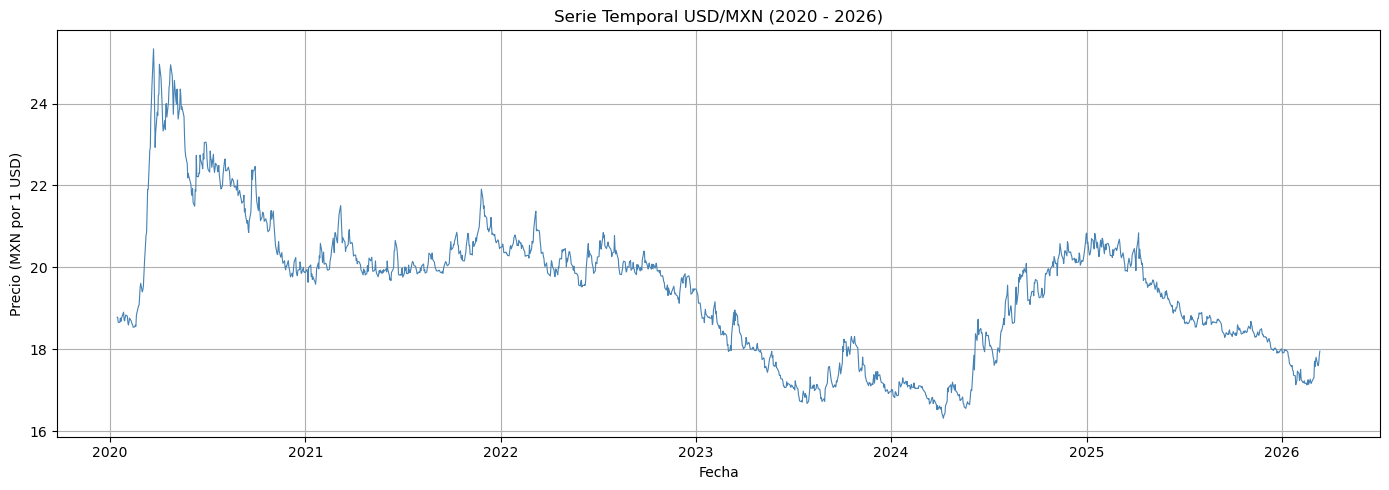

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=0.8)
plt.title('Serie Temporal USD/MXN (2020 - 2026)')
plt.xlabel('Fecha')
plt.ylabel('Precio (MXN por 1 USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Usamos solo el precio de cierre(array) 2D 
prices = df['Price'].values.reshape(-1, 1)

# Normalizar entre 0 y 1
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices).flatten()

n_steps = 50  

def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

X, y = create_sequences(prices_scaled, n_steps)

# Split 70% train / 15% val / 15% test
n = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X[:n_train],                    y[:n_train]
X_val,   y_val   = X[n_train:n_train + n_val],     y[n_train:n_train + n_val]
X_test,  y_test  = X[n_train + n_val:],            y[n_train + n_val:]

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (1090, 50)  y_train: (1090, 1)
X_val:   (233, 50)
X_test:  (235, 50)


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X = X
        self.y = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, y_train),
    'eval':  TimeSeriesDataset(X_val, y_val),
    'test':  TimeSeriesDataset(X_test, train=False)
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval':  DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test':  DataLoader(dataset['test'],  shuffle=False, batch_size=64)
}

print('DataLoaders listos')
print(f'Batches train: {len(dataloader["train"])}')

DataLoaders listos
Batches train: 18


In [ ]:
class MLP(torch.nn.Module):
    def __init__(self, n_in=50, n_out=1):
        super().__init__()
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(n_in, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, n_out)
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)  
        x = self.fc(x)
        return x

mlp = MLP()
print(mlp)

MLP(
  (fc): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [12]:
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')

def fit(model, dataloader, epochs=100):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs+1))
    for epoch in bar:
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
        bar.set_description(f"loss {np.mean(train_loss):.5f} val_loss {np.mean(eval_loss):.5f}")

def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X = batch
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds

Usando: cuda


In [13]:
fit(mlp, dataloader)

loss 0.00040 val_loss 0.00052: 100%|██████████| 100/100 [00:06<00:00, 14.68it/s]


In [14]:
from sklearn.metrics import mean_squared_error

y_pred = predict(mlp, dataloader['test'])

# Desnormalizar para obtener precios reales en MXN
y_pred_real = scaler.inverse_transform(y_pred.cpu().numpy())
y_test_real = scaler.inverse_transform(y_test)

mse = mean_squared_error(y_test_real, y_pred_real)
print(f'MSE: {mse:.5f}')
print(f'RMSE: {mse**0.5:.4f} MXN')

MSE: 0.01164
RMSE: 0.1079 MXN


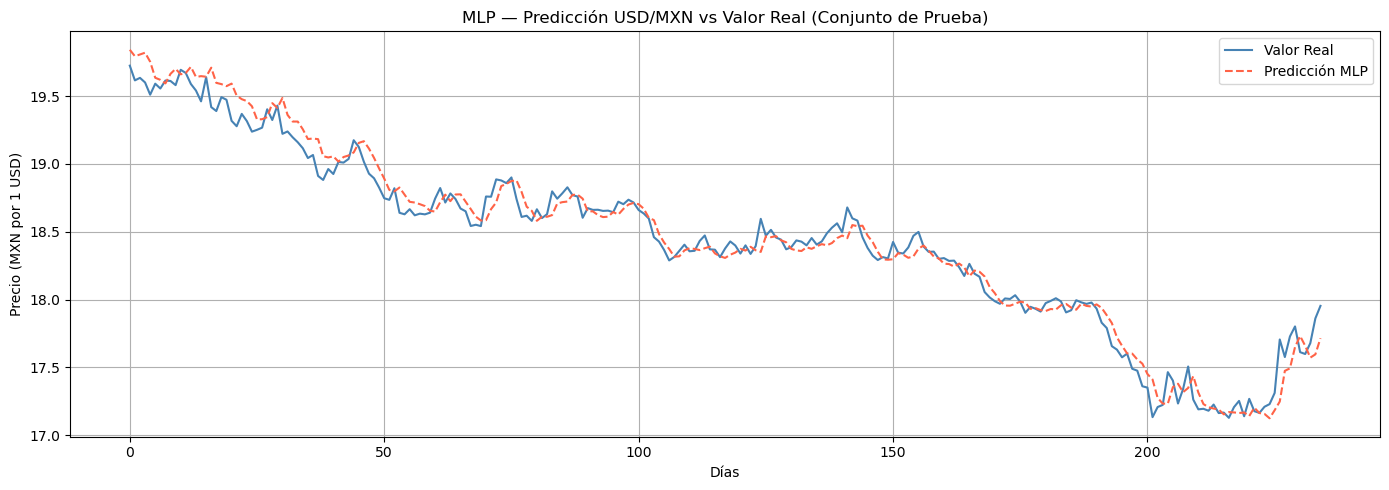

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, label='Valor Real', color='steelblue', linewidth=1.5)
plt.plot(y_pred_real, label='Predicción MLP', color='tomato', linewidth=1.5, linestyle='--')
plt.title('MLP — Predicción USD/MXN vs Valor Real (Conjunto de Prueba)')
plt.xlabel('Días')
plt.ylabel('Precio (MXN por 1 USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

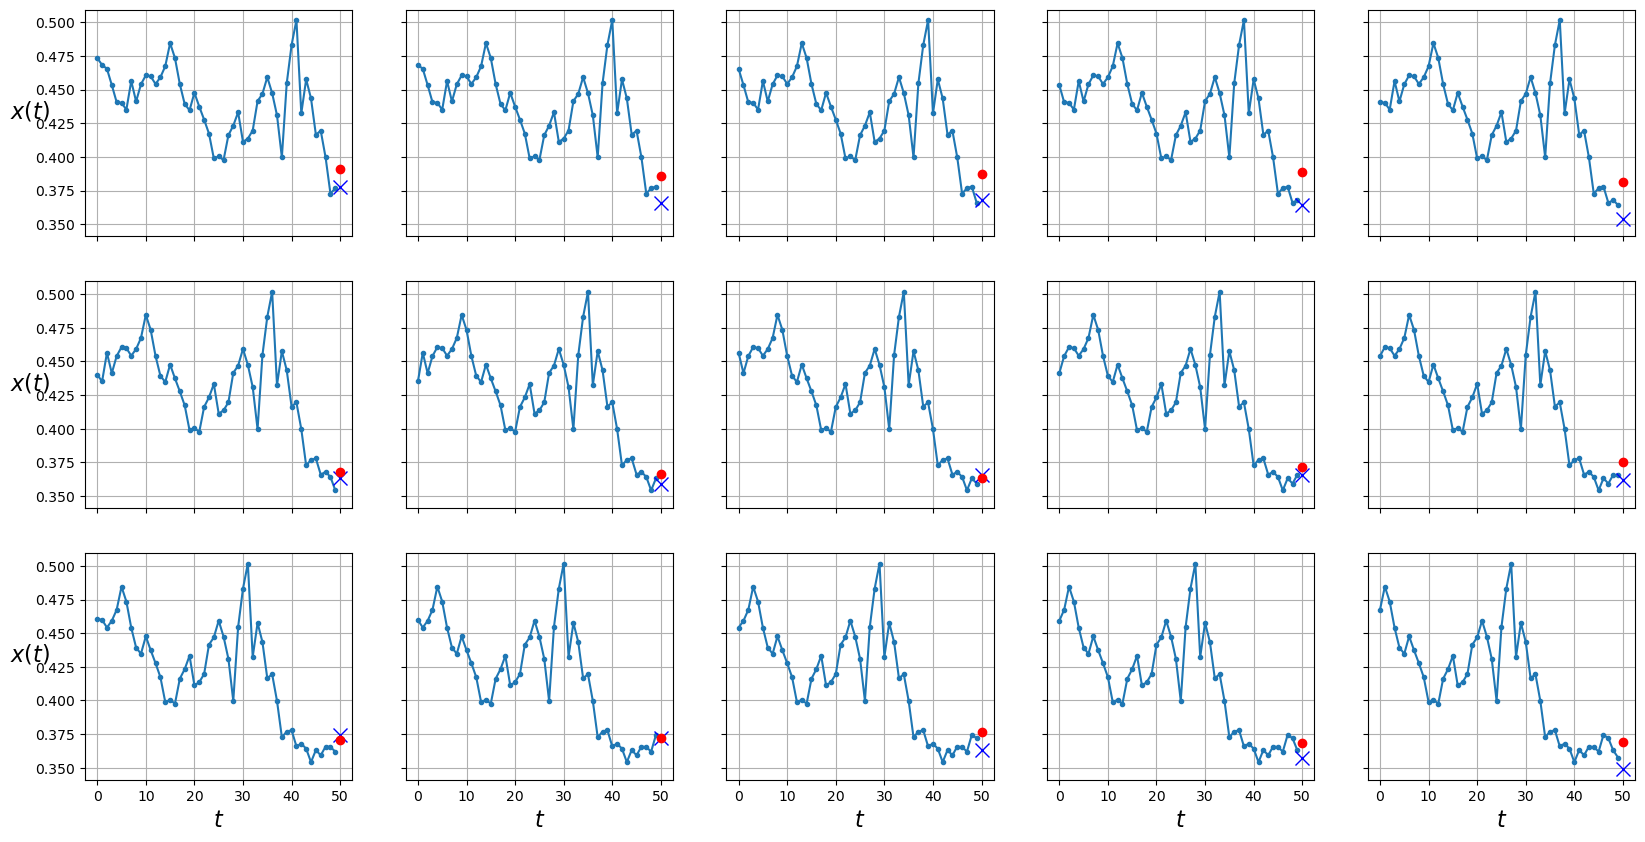

0.00014284752251114696


In [16]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            plt.plot(series[ix], ".-")
            if y is not None:
                plt.plot(len(series[ix]), y[ix], "bx", markersize=10)
            if y_pred is not None:
                plt.plot(len(series[ix]), y_pred[ix], "ro")
            plt.grid(True)
            if x_label and row == r - 1:
                plt.xlabel(x_label, fontsize=16)
            if y_label and col == 0:
                plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.show()

y_pred = predict(mlp, dataloader['test'])
plot_series(X_test, y_test, y_pred.cpu().numpy())
print(mean_squared_error(y_test, y_pred.cpu().numpy()))

# CONCLUSIONES

El modelo MLP implementado con una arquitectura de 50→128→64→1 y una ventana deslizante de 50 días logró predecir el tipo de cambio USD/MXN con un RMSE de 0.1079 MXN, representando un error relativo menor al 1% respecto al precio promedio. El modelo capturó correctamente la tendencia general bajista del período 2020-2026, demostrando que un perceptrón multicapa es capaz de aprender patrones en series temporales financieras cuando estas presentan comportamientos graduales y sostenidos. Sin embargo presenta limitaciones ante movimientos bruscos del mercado — como caídas repentinas o recuperaciones abruptas — debido a que trata los 50 días de entrada como features independientes sin considerar el orden secuencial ni las dependencias temporales entre ellos. A pesar de esta limitación, el MLP resultó ser el modelo más preciso entre los evaluados para este dataset, lo cual se explica por el tamaño moderado del conjunto de datos (1608 registros) donde modelos más simples tienden a generalizar mejor.